# Build Bryant 2024 Holes Test Data

Clip the aligned 4 m WSE and DEM rasters to a 1028 x 1028 top-right window and write compressed GeoTIFFs for tests.

In [1]:
# 0. Configure paths and imports.
import os
from pathlib import Path

import matplotlib.pyplot as plt
import rasterio
from rasterio.windows import Window

os.chdir("/workspace")

path_d = {
    "src_dir": Path("tests/data/bryantTechnicalNoteResolution2024"),
    "out_dir": Path("tests/data/bryantTechnicalNoteResolution2024_holes"),
}

src_fp_d = {
    "dem": path_d["src_dir"] / "dem_04m.tif",
    "wse": path_d["src_dir"] / "wse_04m.tif",
}

out_fp_d = {
    "dem": path_d["out_dir"] / "dem_04m.tif",
    "wse": path_d["out_dir"] / "wse_04m.tif",
}

path_d["out_dir"].mkdir(parents=True, exist_ok=True)

In [2]:
# 1. Build a top-right crop window shared by both aligned rasters.
clip_size = 1028

with rasterio.open(src_fp_d["dem"]) as dem_src, rasterio.open(src_fp_d["wse"]) as wse_src:
    assert dem_src.shape == wse_src.shape
    assert dem_src.transform == wse_src.transform
    assert dem_src.crs == wse_src.crs
    assert dem_src.width >= clip_size and dem_src.height >= clip_size

    window = Window(dem_src.width - clip_size, 0, clip_size, clip_size)
    out_transform = dem_src.window_transform(window)

window

Window(col_off=2332, row_off=0, width=1028, height=1028)

In [3]:
# 2. Write compressed clipped rasters using the same spatial window.
meta_d = {}

for key, src_fp in src_fp_d.items():
    with rasterio.open(src_fp) as src:
        data = src.read(1, window=window)
        profile = src.profile.copy()
        profile.update(
            height=clip_size,
            width=clip_size,
            transform=out_transform,
            compress="DEFLATE",
            predictor=3,
            zlevel=6,
            tiled=True,
            blockxsize=256,
            blockysize=256,
        )

        with rasterio.open(out_fp_d[key], "w", **profile) as dst:
            dst.write(data, 1)

    with rasterio.open(out_fp_d[key]) as src:
        meta_d[key] = {
            "path": str(out_fp_d[key]),
            "shape": src.shape,
            "res": src.res,
            "bounds": src.bounds,
            "compress": src.profile.get("compress"),
        }

with rasterio.open(out_fp_d["dem"]) as dem_src, rasterio.open(out_fp_d["wse"]) as wse_src:
    assert dem_src.shape == wse_src.shape == (clip_size, clip_size)
    assert dem_src.transform == wse_src.transform
    assert dem_src.bounds == wse_src.bounds

meta_d

{'dem': {'path': 'tests/data/bryantTechnicalNoteResolution2024_holes/dem_04m.tif', 'shape': (1028, 1028), 'res': (4.0, 4.0), 'bounds': BoundingBox(left=32366718.0, bottom=5598724.0, right=32370830.0, top=5602836.0), 'compress': 'deflate'}, 'wse': {'path': 'tests/data/bryantTechnicalNoteResolution2024_holes/wse_04m.tif', 'shape': (1028, 1028), 'res': (4.0, 4.0), 'bounds': BoundingBox(left=32366718.0, bottom=5598724.0, right=32370830.0, top=5602836.0), 'compress': 'deflate'}}

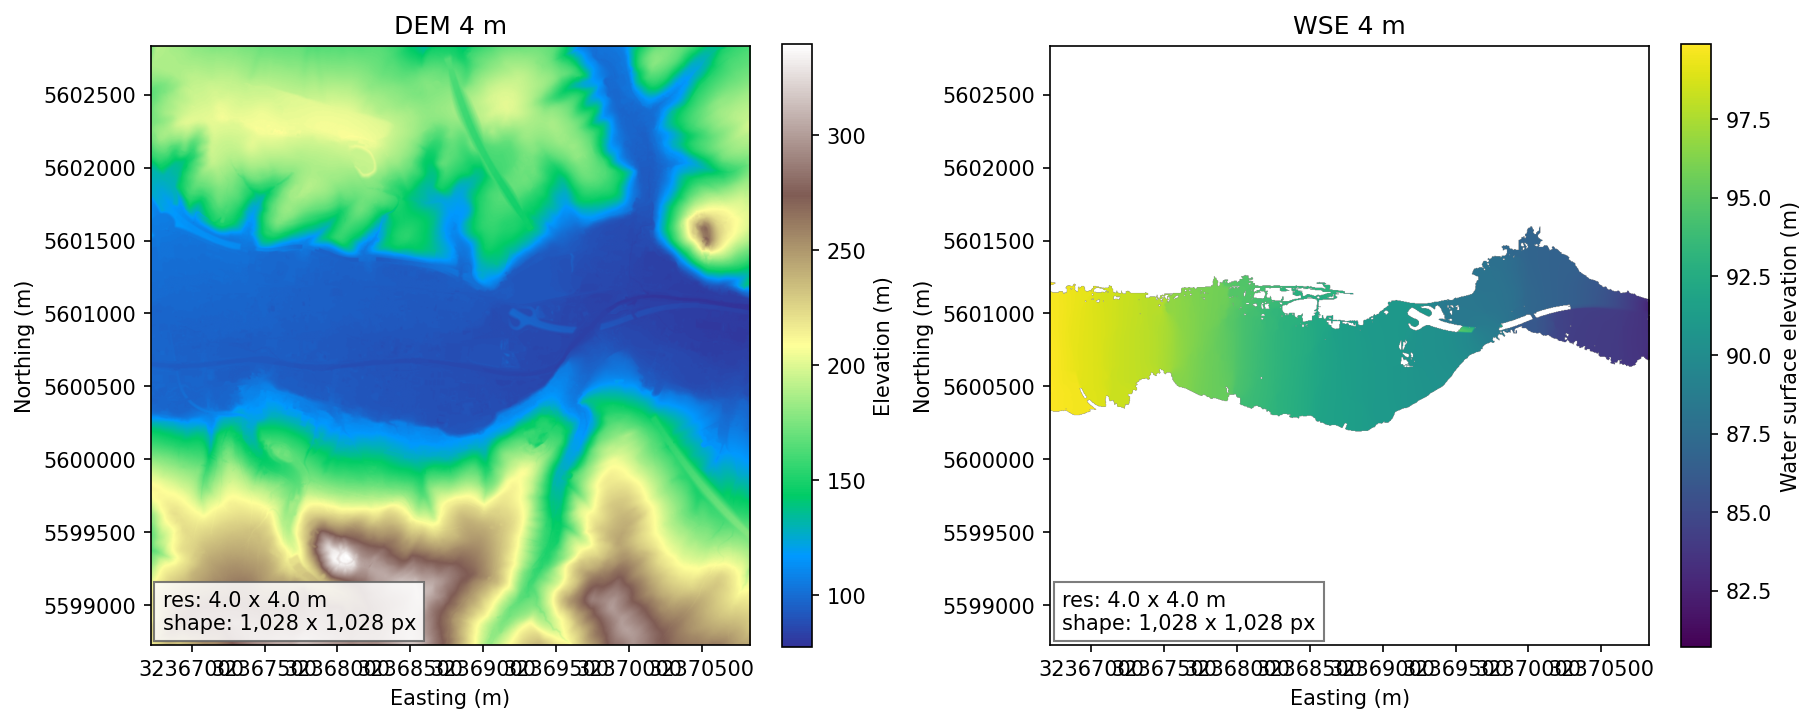

In [4]:
# 3. Plot the clipped rasters with resolution and shape annotations.
style_d = {
    "dem": {"title": "DEM 4 m", "cmap": "terrain", "label": "Elevation (m)"},
    "wse": {"title": "WSE 4 m", "cmap": "viridis", "label": "Water surface elevation (m)"},
}

fig, ax_ar = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for ax, key in zip(ax_ar, ["dem", "wse"]):
    with rasterio.open(out_fp_d[key]) as src:
        data = src.read(1, masked=True)
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
        res_x, res_y = src.res
        height, width = data.shape

    im = ax.imshow(data, extent=extent, cmap=style_d[key]["cmap"])
    ax.set_title(style_d[key]["title"])
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.ticklabel_format(style="plain")
    ax.text(
        0.02,
        0.02,
        f"res: {res_x:.1f} x {res_y:.1f} m\nshape: {width:,} x {height:,} px",
        transform=ax.transAxes,
        va="bottom",
        ha="left",
        bbox={"facecolor": "white", "edgecolor": "0.4", "alpha": 0.85, "pad": 4},
    )
    fig.colorbar(im, ax=ax, shrink=0.85, label=style_d[key]["label"])

plt.show()